## Código numérico para doble barrera

In [44]:
### AJUSTA LOS PARÁMETROS ################


V0 = 0.4          # eV
L_barrera = 7    # nm
L_pozo = 4       # nm
m_rel = 0.98      # masa efectiva relativa
Emin = 0.001      # eV
Emax = 0.6        # eV

# Número de puntos de energía
num_puntos = 5000

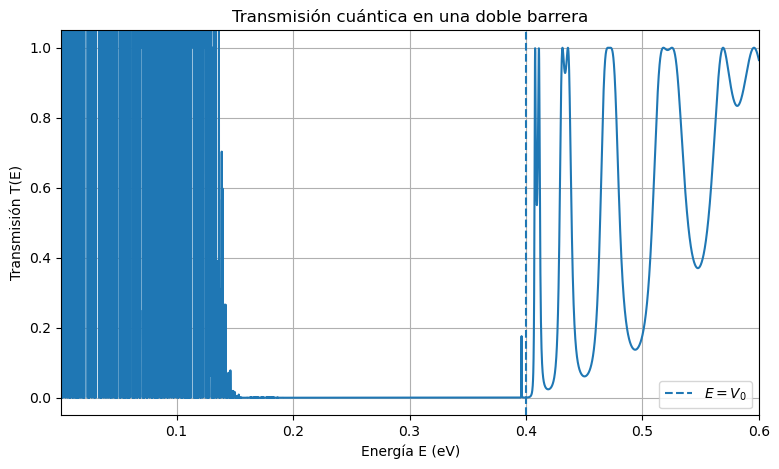

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONSTANTES
# ============================================================

# hbar^2 / (2 m0) en eV nm^2
hbar2_2m0 = 0.0380998


# ============================================================
# FUNCIONES
# ============================================================

def calcular_k(E, V, m_rel):
    """
    Calcula el número de onda k en una región de potencial V.

    E y V están en eV.
    m_rel es la masa efectiva relativa a m0.

    Si E > V, k es real.
    Si E < V, k es imaginario.
    """

    energia_cinetica = E - V

    k = np.sqrt(energia_cinetica * m_rel / hbar2_2m0 + 0j)

    return k


def matriz_D(k):
    """
    Matriz dinámica para imponer continuidad de psi y dpsi/dx.

    psi = A exp(ikx) + B exp(-ikx)
    """

    D = np.array([[1, 1],
                  [k, -k]], dtype=complex)

    return D


def matriz_P(k, L):
    """
    Matriz de propagación en una región de longitud L.

    L está en nm.
    """

    P = np.array([[np.exp(1j * k * L), 0],
                  [0, np.exp(-1j * k * L)]], dtype=complex)

    return P


def transmision_una_energia(E, V0, L_barrera, L_pozo, m_rel):
    """
    Calcula la transmisión para una doble barrera:

        0 - V0 - 0 - V0 - 0

    Región 1: potencial 0
    Región 2: barrera V0
    Región 3: pozo 0
    Región 4: barrera V0
    Región 5: potencial 0

    L_barrera: anchura de cada barrera en nm
    L_pozo: separación entre barreras en nm
    """

    # Potenciales de las 5 regiones
    potenciales = [0, V0, 0, V0, 0]

    # Longitudes de las regiones finitas 2, 3 y 4
    longitudes = [L_barrera, L_pozo, L_barrera]

    # Números de onda en cada región
    k = []

    for V in potenciales:
        k.append(calcular_k(E, V, m_rel))

    # Matriz total que conecta región 1 con región 5
    M = np.identity(2, dtype=complex)

    # Pasamos de región 1 a región 2, propagamos región 2,
    # pasamos a región 3, propagamos región 3,
    # pasamos a región 4, propagamos región 4,
    # pasamos a región 5.

    for i in range(4):

        D_i = matriz_D(k[i])
        D_sig = matriz_D(k[i + 1])

        # Interfaz i -> i+1
        I = np.linalg.inv(D_sig) @ D_i

        M = I @ M

        # Si la siguiente región es finita, propagamos dentro de ella
        # Las regiones finitas son 2, 3 y 4, que corresponden a i+1 = 1,2,3
        if i + 1 in [1, 2, 3]:
            L = longitudes[i]
            P = matriz_P(k[i + 1], L)
            M = P @ M

    # Tenemos:
    # [t, 0]^T = M [1, r]^T
    #
    # De la segunda ecuación:
    # 0 = M21 + M22 r
    # r = -M21 / M22
    #
    # Luego:
    # t = M11 + M12 r

    r = -M[1, 0] / M[1, 1]
    t = M[0, 0] + M[0, 1] * r

    # Como la región izquierda y derecha tienen el mismo potencial y masa:
    T = np.abs(t)**2

    return T.real


def calcular_transmision(Emin, Emax, num_puntos, V0, L_barrera, L_pozo, m_rel):
    """
    Calcula T(E) en un rango de energías.
    """

    energias = np.linspace(Emin, Emax, num_puntos)
    transmisiones = []

    for E in energias:
        T = transmision_una_energia(E, V0, L_barrera, L_pozo, m_rel)
        transmisiones.append(T)

    transmisiones = np.array(transmisiones)

    return energias, transmisiones


# ============================================================
# PROGRAMA PRINCIPAL
# ============================================================

energias, transmisiones = calcular_transmision(
    Emin,
    Emax,
    num_puntos,
    V0,
    L_barrera,
    L_pozo,
    m_rel
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(energias, transmisiones)

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")
plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Transmisión cuántica en una doble barrera")
plt.grid(True)
plt.legend()
plt.ylim(-0.05, 1.05)
plt.xlim(Emin, Emax)
plt.show()